Shape: (8804, 37)

Columns:
['SI_No', 'vessel', 'refno', 'occurrencedate', 'reportdate', 'defect_status', 'location', 'port', 'incidentdetails', 'incidenteventdetails', 'immediateaction', 'incident_category', 'possibility_recurrence', 'areaofconcern', 'detailedextentofdamageinjury', 'directcause', 'indirectcause', 'rootcause', 'proposedcorrectiveactions', 'corrective_action', 'leariningpotential', 'severityofincident', 'revisedincidentcategory', 'cause_analysis', 'accident_details', 'lessionlearnt', 'reviewcomments', 'closingnote', 'closingdate', 'injured_person_name', 'injured_person_rank', 'otherrank', 'otheruser', 'injuryaccidentcategory', 'injured_part', 'other_part', 'source_file']

Duplicates:
0

Missing Values:
SI_No                              0
vessel                             0
refno                              0
occurrencedate                   757
reportdate                         0
defect_status                      0
location                           0
port         

                                             |                                                          | [  0…


Sweetviz Failed:
left cannot be >= right

Generating Profile Report...


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|███████████████████████████████████████████████████████████████████████████████████████████████| 37/37 [00:03<00:00,  9.35it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Saved: adi_profile_report.html
Saved: adi_dashboard.html

Generated Files:

1. adi_sweetviz_report.html
2. adi_profile_report.html
3. adi_dashboard.html



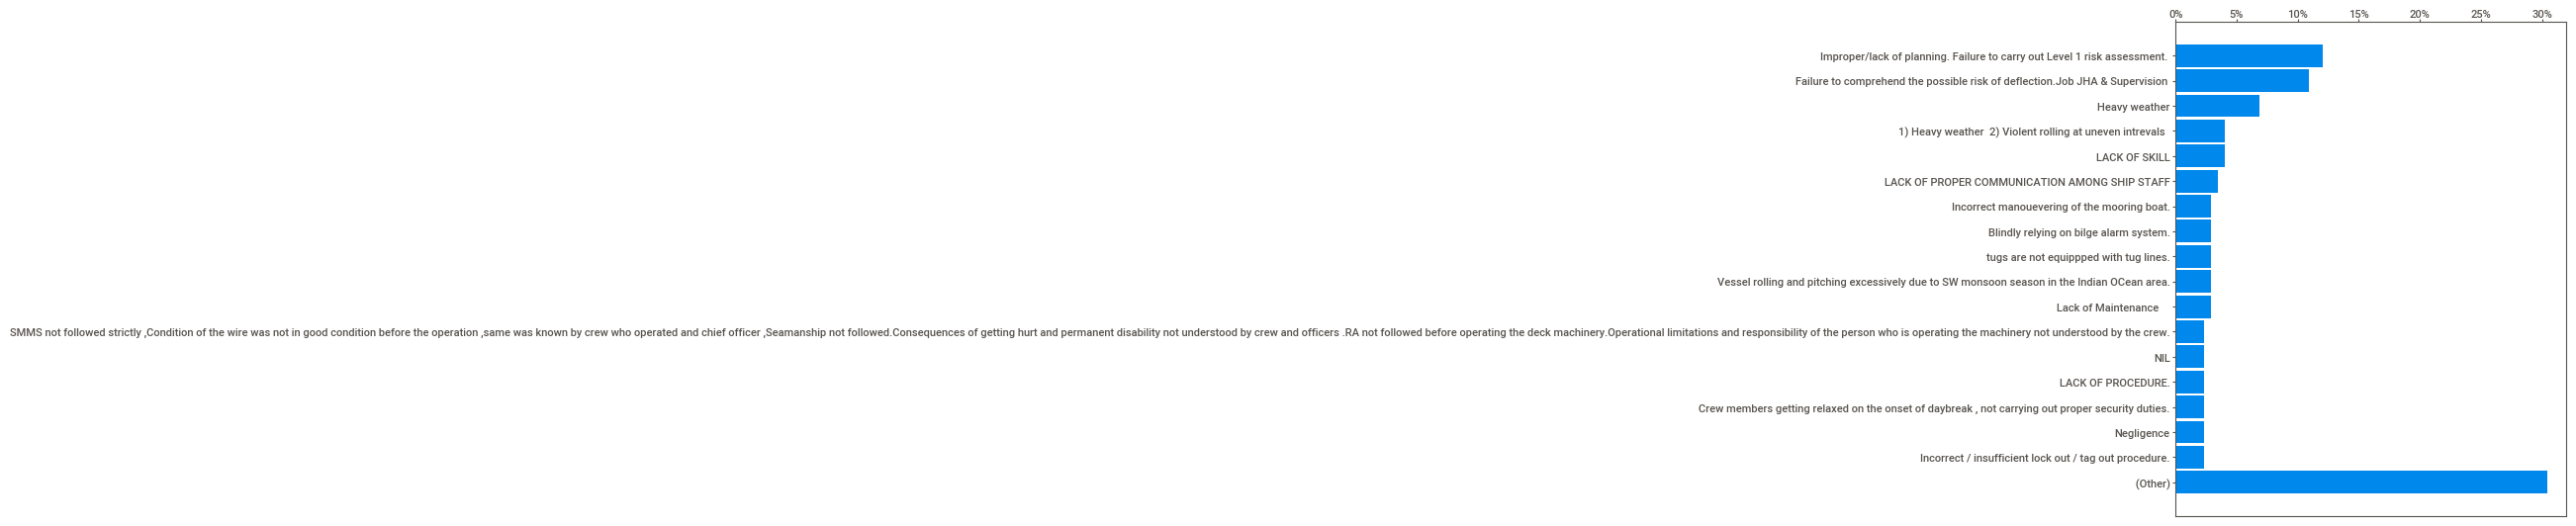

In [3]:
import pandas as pd
import numpy as np
import sweetviz as sv
from ydata_profiling import ProfileReport
import plotly.express as px

# ==========================
# LOAD DATA
# ==========================

file="merged_ADI_final.xlsx"

df=pd.read_excel(
    file,
    dtype=str
)

print("Shape:",df.shape)

print("\nColumns:")
print(list(df.columns))

# ==========================
# STANDARDIZE EMPTY VALUES
# ==========================

df=df.replace(
    [
        "",
        "NA",
        "N/A",
        "na",
        "n/a",
        "NULL",
        "null",
        "nan"
    ],
    np.nan
)

# ==========================
# BASIC SUMMARY
# ==========================

print("\nDuplicates:")
print(
    df.duplicated().sum()
)

print("\nMissing Values:")
print(
    df.isna().sum()
)

print("\nUnique Values:")
print(
    df.nunique()
)

# ==========================
# SWEETVIZ SAFE VERSION
# ==========================

print("\nGenerating Sweetviz...")

sweet_df=df.copy()

remove=[]

for col in sweet_df.columns:

    try:

        uniq=sweet_df[col].nunique()

        avg=(
            sweet_df[col]
            .astype(str)
            .str.len()
            .mean()
        )

        if (
            uniq>100
            or
            avg>150
        ):

            remove.append(col)

    except:
        pass

sweet_df=sweet_df.drop(
    columns=remove,
    errors="ignore"
)

print(
    "\nExcluded Columns:"
)

print(remove)

try:

    report=sv.analyze(

        sweet_df,

        pairwise_analysis="off"

    )

    report.show_html(

        filepath="adi_sweetviz_report.html",

        open_browser=False

    )

    print(
        "Saved: adi_sweetviz_report.html"
    )

except Exception as e:

    print(
        "\nSweetviz Failed:"
    )

    print(e)

# ==========================
# PROFILE REPORT
# ==========================

print("\nGenerating Profile Report...")

profile=ProfileReport(

    df,

    title="ADI EDA",

    explorative=True,

    minimal=True

)

profile.to_file(
    "adi_profile_report.html"
)

print(
    "Saved: adi_profile_report.html"
)

# ==========================
# CUSTOM DASHBOARD
# ==========================

html=[]

html.append("""
<html>
<head>
<title>ADI Dashboard</title>
</head>
<body>

<h1>ADI EDA Dashboard</h1>
""")

# ==========================
# MISSING %
# ==========================

missing=(

    df
    .isna()
    .mean()

)*100

missing=missing[
    missing>0
]

if len(missing)>0:

    fig=px.bar(

        x=missing.index,

        y=missing.values,

        title="Missing Percentage"

    )

    html.append(
        fig.to_html(
            full_html=False
        )
    )

# ==========================
# TOP CATEGORIES
# ==========================

for col in df.columns:

    try:

        temp=(

            df[col]

            .dropna()

            .value_counts()

            .head(10)

        )

        if (

            len(temp)>1

            and

            df[col].nunique()<30

        ):

            fig=px.bar(

                x=temp.index,

                y=temp.values,

                title=col

            )

            html.append(

                fig.to_html(
                    full_html=False
                )

            )

    except:
        pass

# ==========================
# UNIQUE VALUES
# ==========================

unique=df.nunique()

fig=px.bar(

    x=unique.index,

    y=unique.values,

    title="Unique Values"

)

html.append(

    fig.to_html(
        full_html=False
    )

)

# ==========================
# RECORDS PER SOURCE
# ==========================

if "source_file" in df.columns:

    temp=(

        df["source_file"]

        .value_counts()

    )

    fig=px.pie(

        names=temp.index,

        values=temp.values,

        title="Records by Source"

    )

    html.append(

        fig.to_html(
            full_html=False
        )

    )

html.append(
"""
</body>
</html>
"""
)

with open(

    "adi_dashboard.html",

    "w",

    encoding="utf-8"

) as f:

    f.write(
        "\n".join(
            html
        )
    )

print(
    "Saved: adi_dashboard.html"
)

# ==========================
# FINISHED
# ==========================

print("\nGenerated Files:")

print(
"""
1. adi_sweetviz_report.html
2. adi_profile_report.html
3. adi_dashboard.html
"""
)